In [1]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import uniform, randint
from xgboost import XGBClassifier
import optuna
import joblib

# 1.Sanity Checks

In [3]:
## Reading the file
df = pd.read_csv('/content/Customer_Churn.csv')

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
## For Data Preparation
# Null values should be treated, if any
# Tenure should be binned to bins of 1-12,13-24..and so on until 61-72.
# TotalCharges column should be numeric
# Column CustomerID should be dropped
# One hot encoding should be applied All categorical columns
# Label encoding should be applied to Churn column - target variable
# Dataset should be didvided into X(independent variables) and y(dependent/target variable) using train test split

In [8]:
# Calculating churn rate
df['Churn'].value_counts(), df['Churn'].value_counts()/len(df)*100

(Churn
 No     5174
 Yes    1869
 Name: count, dtype: int64,
 Churn
 No     73.463013
 Yes    26.536987
 Name: count, dtype: float64)

**Churn rate** is 26.53%

# 2.Data Preparation

In [9]:
# Customer_ID column is not needed as it has no relevance with churn prediction
df.drop('customerID',axis=1,inplace=True)

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### 2.1.Checking for null values

All data types seem to good now but there are some null values in TotalCharges column after the datatype conversion

In [12]:
# Checking null values
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [13]:
# Since these rows don't look like outliers and total %< 1% of total rows, they can be dropped
df.dropna(inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### 2.2.Converting TotalCharges to numeric datatype

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

### 2.3.Null Value Treatment

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [17]:
df[df['TotalCharges'].isnull()==True]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Since the number of null values is less than 1% and it doesn;t contain any outlier info, we can drop these

In [18]:
df.dropna(inplace=True)

### 2.4.Creating new column tenure_binned and dropping the original tenure column

In [19]:
# Define the bins and labels for tenure
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']

# Apply binning to 'tenure' column in df_encoded
df['tenure_binned'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

# Drop the original 'tenure' column
df = df.drop('tenure', axis=1)

print("Value counts for 'tenure_binned' in df_encoded:")
print(df['tenure_binned'].value_counts())

display(df.head())

Value counts for 'tenure_binned' in df_encoded:
tenure_binned
1-12     2175
61-72    1407
13-24    1024
25-36     832
49-60     832
37-48     762
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_binned
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12


In [20]:
df['tenure_binned'].dtype

CategoricalDtype(categories=['1-12', '13-24', '25-36', '37-48', '49-60', '61-72'], ordered=True, categories_dtype=object)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7032 non-null   object  
 1   SeniorCitizen     7032 non-null   int64   
 2   Partner           7032 non-null   object  
 3   Dependents        7032 non-null   object  
 4   PhoneService      7032 non-null   object  
 5   MultipleLines     7032 non-null   object  
 6   InternetService   7032 non-null   object  
 7   OnlineSecurity    7032 non-null   object  
 8   OnlineBackup      7032 non-null   object  
 9   DeviceProtection  7032 non-null   object  
 10  TechSupport       7032 non-null   object  
 11  StreamingTV       7032 non-null   object  
 12  StreamingMovies   7032 non-null   object  
 13  Contract          7032 non-null   object  
 14  PaperlessBilling  7032 non-null   object  
 15  PaymentMethod     7032 non-null   object  
 16  MonthlyCharges    7032 non-nu

### 2.5.Label Encoding for Target Variable
First, I'll convert the `Churn` column into a numerical format, mapping 'Yes' to 1 and 'No' to 0. This is necessary because machine learning models typically require numerical input.

In [22]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


### 2.6.One-Hot Encoding for Categorical Features
Next, I'll apply one-hot encoding to all remaining categorical columns. This process converts categorical variables into a numerical format that can be provided to machine learning algorithms, preventing them from assuming any ordinal relationship where none exists.

In [23]:
# Identify categorical columns for one-hot encoding (excluding 'Churn' which is now numeric)
categorical_cols = df.select_dtypes(include=['object','category']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df_encoded.head())

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_binned_13-24,tenure_binned_25-36,tenure_binned_37-48,tenure_binned_49-60,tenure_binned_61-72
0,0,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False
1,0,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False
2,0,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False
3,0,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False


In [24]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   MonthlyCharges                         7032 non-null   float64
 2   TotalCharges                           7032 non-null   float64
 3   Churn                                  7032 non-null   int64  
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetS

### 2.7.Splitting Data into Training and Testing Sets
Finally, I'll split the dataset into independent variables (X) and the target variable (y). Then, I'll divide these into training and testing sets using a 80/20 split (test_size=0.2) to prepare for model training and evaluation.

In [25]:
# Separate features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

display(X_train.head())

Shape of X_train: (5625, 34)
Shape of X_test: (1407, 34)
Shape of y_train: (5625,)
Shape of y_test: (1407,)


,SeniorCitizen,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_binned_13-24,tenure_binned_25-36,tenure_binned_37-48,tenure_binned_49-60,tenure_binned_61-72
6030,0,49.05,2076.20,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False
3410,0,53.40,188.70,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False
5483,0,77.75,4458.15,False,True,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False
5524,0,54.65,2553.70,True,True,True,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
6337,0,100.90,5448.60,False,True,True,True,False,True,True,False,False,True,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,True,False,False,False,True,False


In [26]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   MonthlyCharges                         7032 non-null   float64
 2   TotalCharges                           7032 non-null   float64
 3   Churn                                  7032 non-null   int64  
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetS

# 3.Model Building

The intention to build a model first without feature scaling is to check how accurate the model's predictions are without scaling

In [27]:
model_dt = DecisionTreeClassifier(random_state=24)
model_dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=24)

### Decision Tree Classifier without Scaling

In [28]:
y_pred_dt = model_dt.predict(X_test)

In [29]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.48      0.50      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.72      0.73      1407





*   Model accurarcy of 73% is really low and also not relevant for imbalanced data(referring to distribution of target variable)
*   Precision, Recall and fi-score metrics (~ 50%) are also really low
*   Lets see if doing Feature Scaling makes any difference





### Random Forest Classifier without Scaling

In [30]:
model_rf = RandomForestClassifier(random_state=24)
model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_test)

In [31]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.61      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.76      0.78      0.77      1407



### Logistic Regression without Scaling

In [32]:
model_lr = LogisticRegression(random_state=24, solver='liblinear')
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



### XGBoost without Scaling

In [41]:
model_xgb = XGBClassifier(random_state=24)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



* Logistic Regression and XGBoost Models seems to me the better choice when data is not yet scaled if we compare F1 score for minority class for all 3 models

# 4.Feature Scaling

### Feature Scaling using StandardScaler
I'll use `StandardScaler` to standardize the features in `X_train` and `X_test`. This transforms the data so that it has a mean of 0 and a standard deviation of 1, which can improve the performance of many machine learning algorithms.

In [33]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the fitted scaler
# Never use fit_transform on your test set. Instead, use the transform method only.
# Using fit_transform on test data causes data leakage, where the model "peeks"
# at the test set's distribution,  leading to biased and over-optimistic performance results.
X_test_scaled = scaler.transform(X_test)

# Converting arrarys back into dataframes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("X_train after scaling (first 5 rows):")
display(X_train_scaled.head())

print("X_test after scaling (first 5 rows):")
display(X_test_scaled.head())

X_train after scaling (first 5 rows):


,SeniorCitizen,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_binned_13-24,tenure_binned_25-36,tenure_binned_37-48,tenure_binned_49-60,tenure_binned_61-72
0,-0.43759,-0.518620,-0.087908,-1.013784,-0.962481,-0.653684,-3.040707,3.040707,-0.845541,-0.885446,-0.529847,-0.529847,-0.635172,-0.529847,-0.728145,-0.529847,1.384749,-0.529847,-0.638757,-0.529847,1.261811,-0.529847,1.247260,-0.518272,-0.561130,0.831397,-0.527645,-0.714758,-0.547427,-0.405407,-0.367407,2.851577,-0.363970,-0.499722
1,-0.43759,-0.374443,-0.921285,0.986404,-0.962481,-0.653684,0.328871,-0.328871,-0.845541,-0.885446,-0.529847,-0.529847,-0.635172,-0.529847,-0.728145,-0.529847,-0.722152,-0.529847,-0.638757,-0.529847,1.261811,-0.529847,-0.801758,-0.518272,-0.561130,-1.202795,1.895214,-0.714758,-0.547427,-0.405407,-0.367407,-0.350683,-0.363970,-0.499722
2,-0.43759,0.432616,0.963781,-1.013784,1.038981,-0.653684,0.328871,-0.328871,1.182675,1.129374,-0.529847,-0.529847,-0.635172,-0.529847,-0.728145,-0.529847,1.384749,-0.529847,-0.638757,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,-0.561130,0.831397,-0.527645,1.399076,-0.547427,-0.405407,-0.367407,-0.350683,2.747477,-0.499722
3,-0.43759,-0.333013,0.122920,0.986404,1.038981,1.529791,0.328871,-0.328871,-0.845541,-0.885446,-0.529847,-0.529847,1.574377,-0.529847,-0.728145,-0.529847,-0.722152,-0.529847,1.565542,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,1.782119,-1.202795,-0.527645,-0.714758,-0.547427,-0.405407,-0.367407,2.851577,-0.363970,-0.499722
4,-0.43759,1.199902,1.401088,-1.013784,1.038981,1.529791,0.328871,-0.328871,1.182675,1.129374,-0.529847,-0.529847,1.574377,-0.529847,-0.728145,-0.529847,-0.722152,-0.529847,-0.638757,-0.529847,1.261811,-0.529847,1.247260,1.929487,-0.561130,-1.202795,-0.527645,-0.714758,1.826727,-0.405407,-0.367407,-0.350683,2.747477,-0.499722


X_test after scaling (first 5 rows):


,SeniorCitizen,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_binned_13-24,tenure_binned_25-36,tenure_binned_37-48,tenure_binned_49-60,tenure_binned_61-72
0,2.285245,-1.315736,-0.341541,0.986404,1.038981,-0.653684,0.328871,-0.328871,1.182675,-0.885446,1.887338,1.887338,-0.635172,1.887338,-0.728145,1.887338,-0.722152,1.887338,-0.638757,1.887338,-0.792512,1.887338,-0.801758,-0.518272,1.782119,-1.202795,-0.527645,-0.714758,-0.547427,-0.405407,-0.367407,-0.350683,-0.36397,2.001112
1,-0.437590,-1.325680,-0.798916,-1.013784,-0.962481,-0.653684,0.328871,-0.328871,1.182675,-0.885446,1.887338,1.887338,-0.635172,1.887338,-0.728145,1.887338,-0.722152,1.887338,-0.638757,1.887338,-0.792512,1.887338,-0.801758,-0.518272,-0.561130,-1.202795,-0.527645,-0.714758,-0.547427,2.466654,-0.367407,-0.350683,-0.36397,-0.499722
2,-0.437590,1.244647,-0.404569,0.986404,1.038981,-0.653684,0.328871,-0.328871,1.182675,1.129374,-0.529847,-0.529847,-0.635172,-0.529847,-0.728145,-0.529847,1.384749,-0.529847,-0.638757,-0.529847,1.261811,-0.529847,1.247260,-0.518272,-0.561130,0.831397,1.895214,-0.714758,-0.547427,2.466654,-0.367407,-0.350683,-0.36397,-0.499722
3,-0.437590,-0.319756,-0.107975,0.986404,1.038981,-0.653684,0.328871,-0.328871,1.182675,-0.885446,-0.529847,-0.529847,1.574377,-0.529847,-0.728145,-0.529847,-0.722152,-0.529847,-0.638757,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,-0.561130,0.831397,-0.527645,-0.714758,1.826727,-0.405407,-0.367407,2.851577,-0.36397,-0.499722
4,-0.437590,-1.168245,-0.933316,-1.013784,-0.962481,-0.653684,-3.040707,3.040707,-0.845541,-0.885446,-0.529847,-0.529847,1.574377,-0.529847,-0.728145,-0.529847,-0.722152,-0.529847,-0.638757,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,-0.561130,-1.202795,-0.527645,-0.714758,-0.547427,-0.405407,-0.367407,-0.350683,-0.36397,-0.499722


# 5.Back to Model Building

In [34]:
print("Shape of X_train:", X_train_scaled.shape)
print("Shape of X_test:", X_test_scaled.shape)

Shape of X_train: (5625, 34)
Shape of X_test: (1407, 34)


### Logistic Regression Classifier with StandardScaler

In [35]:
model_lr_scaled = LogisticRegression(random_state=24, solver='liblinear')
model_lr_scaled.fit(X_train_scaled, y_train)
y_pred_lr_scaled = model_lr_scaled.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr_scaled))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



### Decision Tree Classifier with StandardScaler

In [36]:
model_dt2 = DecisionTreeClassifier(random_state=24)
model_dt2.fit(X_train_scaled,y_train)

y_pred_dt2 = model_dt.predict(X_test_scaled)

In [37]:
print(classification_report(y_test,y_pred_dt2))

              precision    recall  f1-score   support

           0       0.84      0.51      0.63      1033
           1       0.35      0.74      0.47       374

    accuracy                           0.57      1407
   macro avg       0.60      0.62      0.55      1407
weighted avg       0.71      0.57      0.59      1407



### Random Forest Classifier with StandardScaler

In [38]:
model_rf2 = RandomForestClassifier(random_state=24)
model_rf2.fit(X_train_scaled,y_train)

y_pred_rf2 = model_rf2.predict(X_test_scaled)

In [39]:
print(classification_report(y_test,y_pred_rf2))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.61      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.76      0.78      0.77      1407



### XGBoost Classifier with StandardScaler

In [40]:
model_xgb = XGBClassifier(random_state=24)
model_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = model_xgb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



* It should be noted that in business cases such as churn prediction, F1 score for minority class is a more decisive metric for model selection than prediction as its 10 time more expensive to get a new customer than to retain an existing one
* DecisionTree classifier seems to perform poorly on minorty class (F1 score: )
* After standardscaling, LogisticRegression and Random Forest Classifier models seem to have comparable F1 scores for minority class (0.53 vs 0.52)
* XGBoostClassifier is clearly takes the lead here with F1 score of 0.55 for minority class

# 6.Feature Scaling using MinMaxscaler
Lets see if using a different kind of sacler improves performance

In [43]:
# Initialize the StandardScaler
scaler_2 = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_scaled_2 = scaler_2.fit_transform(X_train)

# Transform the test data using the fitted scaler
# Never use fit_transform on your test set. Instead, use the transform method only.
# Using fit_transform on test data causes data leakage, where the model "peeks"
# at the test set's distribution,  leading to biased and over-optimistic performance results.
X_test_scaled_2 = scaler_2.transform(X_test)

# Converting arrarys back into dataframes
X_train_scaled_2 = pd.DataFrame(X_train_scaled_2, columns=X_train.columns)
X_test_scaled_2 = pd.DataFrame(X_test_scaled_2, columns=X_test.columns)

print("X_train after scaling (first 5 rows):")
display(X_train_scaled_2.head())

print("X_test after scaling (first 5 rows):")
display(X_test_scaled_2.head())

X_train after scaling (first 5 rows):


,SeniorCitizen,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_binned_13-24,tenure_binned_25-36,tenure_binned_37-48,tenure_binned_49-60,tenure_binned_61-72
0,0.0,0.306468,0.237406,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.349751,0.019600,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.592040,0.512269,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.362189,0.292507,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.822388,0.626561,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


X_test after scaling (first 5 rows):


,SeniorCitizen,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_binned_13-24,tenure_binned_25-36,tenure_binned_37-48,tenure_binned_49-60,tenure_binned_61-72
0,1.0,0.067164,0.171118,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.064179,0.051581,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.835821,0.154645,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.366169,0.232162,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.111443,0.016455,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 7.Back to Model Building again

### Logistic Regression with MinMaxScaler

In [47]:
model_lr_minmax = LogisticRegression(random_state=24, solver='liblinear')
model_lr_minmax.fit(X_train_scaled_2, y_train)
y_pred_lr_minmax = model_lr_minmax.predict(X_test_scaled_2)

print(classification_report(y_test, y_pred_lr_minmax))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [46]:
model_xgb_minmax = XGBClassifier(random_state=24)
model_xgb_minmax.fit(X_train_scaled_2, y_train)
y_pred_xgb_minmax = model_xgb_minmax.predict(X_test_scaled_2)

print(classification_report(y_test, y_pred_xgb_minmax))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



Observations:
1. We can see that accuracy and classification metrics like precision, recall, fi-score hasn't changed after changing feature scaling technique. So we'll continue with Standardscaling
2. In this scenario, techniques like PCA/LDA won't be effective
3. We'll need to experiment with class imbalance handling techniques like Resampling, SMOTE/SMOTENN, ADASYN
4. Logisticn Regression and XGBoost models are the model we're going to experiment with  as they have the highest F1 score for minority class (0.53, 0.55) among all models. Accuracy - although not that important is high as well(0.78)



# 8.Handling Class Imbalance

### 8.1.Using SMOTENN(Synthetic Minority Over Sampling Technique + Edited Nearest Neighbors)

* Note: Always resample training data, not your testing data. Otherwise some of the synthetic data might sneak into the test data and the model predictions will be biased
* We'll be using X_train_scaled obtained using standardscaler and y_train


In [48]:
sm =SMOTEENN()
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

In [49]:
print("Shape of X_train before SMOTEENN:", X_train_scaled.shape)
print("Shape of y_train before SMOTEENN:", y_train.shape)
print("Shape of X_train after SMOTEENN:", X_train_resampled.shape)
print("Shape of y_train after SMOTEENN:", y_train_resampled.shape)

print("Value counts for y_train_smotenn_resampled:")
print(y_train_resampled.value_counts())

Shape of X_train before SMOTEENN: (5625, 34)
Shape of y_train before SMOTEENN: (5625,)
Shape of X_train after SMOTEENN: (5209, 34)
Shape of y_train after SMOTEENN: (5209,)
Value counts for y_train_smotenn_resampled:
Churn
1    2961
0    2248
Name: count, dtype: int64


# 9.Back to Model Building again

### Logistic Regression with StandardScaler, SMOTEENN

In [50]:
# Lets try a Logistic Regression model
model_smnn_lr = LogisticRegression(random_state=24, solver='liblinear')
model_smnn_lr.fit(X_train_resampled,y_train_resampled)
y_pred_smnn_lr = model_smnn_lr.predict(X_test_scaled)
print(classification_report(y_test,y_pred_smnn_lr))

              precision    recall  f1-score   support

           0       0.92      0.64      0.76      1033
           1       0.46      0.84      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.69      0.71      1407



### XGBoost Classifier with StandardScaler, SMOTEENN

In [52]:
model_smnn_xgb = XGBClassifier(random_state=24)
model_smnn_xgb.fit(X_train_resampled,y_train_resampled)
y_pred_smnn_xgb = model_smnn_xgb.predict(X_test_scaled)
print(classification_report(y_test,y_pred_smnn_xgb))

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1033
           1       0.49      0.77      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407



* So far, XGBoostClassifier with StandardScaler, SMOTENN has given the best prediction quality (F Score for minority class: 0.60)
* SMOTENN doesn't seem to be improving prediction quality when accompanied with Logistic Regression model
* Since SMOTE is a method of oversampling and ENN is a method of data cleaning, lets just try the best model XGBoostClassifier with SMOTE only

### 10.Using SMOTE (Synthetic Minority Over-sampling Technique)

In [53]:
# Print shape before SMOTE
print("Shape of X_train before SMOTE:", X_train_scaled.shape)
print("Shape of y_train before SMOTE:", y_train.shape)

smote = SMOTE(random_state=24)
X_train_smote_resampled, y_train_smote_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nShape of X_train_smote_resampled after SMOTE:", X_train_smote_resampled.shape)
print("Shape of y_train_smote_resampled after SMOTE:", y_train_smote_resampled.shape)
print("Value counts for y_train_smote_resampled:")
print(y_train_smote_resampled.value_counts())

Shape of X_train before SMOTE: (5625, 34)
Shape of y_train before SMOTE: (5625,)

Shape of X_train_smote_resampled after SMOTE: (8260, 34)
Shape of y_train_smote_resampled after SMOTE: (8260,)
Value counts for y_train_smote_resampled:
Churn
1    4130
0    4130
Name: count, dtype: int64


# 11.Back to Model Building (with SMOTE)

### Logistic Regression with StandardScaler, SMOTE

In [54]:
model_smote_lr = LogisticRegression(random_state=24, solver='liblinear')
model_smote_lr.fit(X_train_smote_resampled, y_train_smote_resampled)
y_pred_smote_lr = model_smote_lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_smote_lr))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



### XGBoost Classifier with StandardScaler, SMOTE

In [55]:
model_smote_xgb = XGBClassifier(random_state=24)
model_smote_xgb.fit(X_train_smote_resampled, y_train_smote_resampled)
y_pred_smote_xgb = model_smote_xgb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_smote_xgb))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1033
           1       0.57      0.56      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



* This time, Logistic Regression with StandardScaler, SMOTE has given the best prediction quality (F1 Score for minority class: 0.61) with accuracy of 0.72
* XGBoost Classifier with StandardScaler, SMOTE actually has a lower prediction quality than expected (F1 scoer for minority class: 0.57) with higher accuracy of 0.77

### 12.Using ADASYN (Adaptive Synthetic Sampling)

In [56]:
# Print shape before ADASYN
print("Shape of X_train before ADASYN:", X_train_scaled.shape)
print("Shape of y_train before ADASYN:", y_train.shape)

adasyn = ADASYN(random_state=24)
X_train_adasyn_resampled, y_train_adasyn_resampled = adasyn.fit_resample(X_train_scaled, y_train)

print("\nShape of X_train_adasyn_resampled after ADASYN:", X_train_adasyn_resampled.shape)
print("Shape of y_train_adasyn_resampled after ADASYN:", y_train_adasyn_resampled.shape)
print("Value counts for y_train_adasyn_resampled:")
print(y_train_adasyn_resampled.value_counts())

Shape of X_train before ADASYN: (5625, 34)
Shape of y_train before ADASYN: (5625,)

Shape of X_train_adasyn_resampled after ADASYN: (8225, 34)
Shape of y_train_adasyn_resampled after ADASYN: (8225,)
Value counts for y_train_adasyn_resampled:
Churn
0    4130
1    4095
Name: count, dtype: int64


# 13.Back to Model Building (with ADASYN)

### Logistic Regression with StandardScaler, ADASYN

In [57]:
model_adasyn_lr = LogisticRegression(random_state=24, solver='liblinear')
model_adasyn_lr.fit(X_train_adasyn_resampled, y_train_adasyn_resampled)
y_pred_adasyn_lr = model_adasyn_lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_adasyn_lr))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.72      0.73      1407



### XGBoost Classifier with StandardScaler, ADASYN

In [62]:
model_adasyn_xgb = XGBClassifier(random_state=24)
model_adasyn_xgb.fit(X_train_adasyn_resampled, y_train_adasyn_resampled)
y_pred_adasyn_xgb = model_adasyn_xgb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_adasyn_xgb))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.55      0.56      0.55       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.76      0.76      0.76      1407



* ADASYN doesn't seem to improve peformance.
* Still now, Logistic Regression with StandardScaler, SMOTE has given the best prediction quality (F1 Score for minority class: 0.61) with accuracy of 0.73
* Close second is XGBoost Classifier with StandardScaler, SMOTEENN model (F1 Score for minority class: 0.60) with accuracy of 0.72

# 14.Cost-Sensitive Learning with XGBoost

### XGBoost Classifier with StandardScaler, Cost-Sensitive (scale_pos_weight)

Using `scale_pos_weight` in XGBoost is a method of handling imbalanced datasets by assigning different weights to the positive and negative classes. This parameter helps the model to pay more attention to the minority class by increasing its weight, thus reducing the number of false negatives.

In [63]:
# Calculate the scale_pos_weight
# A common practice is to set it to (count(negative_class) / count(positive_class))
neg_count = y_train.value_counts()[0] # Count of 'No Churn' (majority class)
pos_count = y_train.value_counts()[1] # Count of 'Churn' (minority class)

scale_pos_weight_value = neg_count / pos_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# Initialize and train XGBoostClassifier with scale_pos_weight
model_xgb_cost_sensitive = XGBClassifier(random_state=24, scale_pos_weight=scale_pos_weight_value)
model_xgb_cost_sensitive.fit(X_train_scaled, y_train)

y_pred_xgb_cost_sensitive = model_xgb_cost_sensitive.predict(X_test_scaled)

print("\nClassification Report for XGBoost with scale_pos_weight:")
print(classification_report(y_test, y_pred_xgb_cost_sensitive))

Calculated scale_pos_weight: 2.76

Classification Report for XGBoost with scale_pos_weight:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1033
           1       0.52      0.65      0.58       374

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.75      0.76      1407



# 15.Cost-Sensitive Learning with ADAboost

### AdaBoost Classifier with StandardScaler, Cost-Sensitive (class_weight)

In [64]:
# Calculate the class weights based on the imbalance in y_train
neg_count = y_train.value_counts()[0] # Count of 'No Churn' (majority class)
pos_count = y_train.value_counts()[1] # Count of 'Churn' (minority class)

# Assign a weight of 1 to the majority class (0) and a higher weight to the minority class (1)
class_weights = {0: 1, 1: neg_count / pos_count}
print(f"Calculated class_weights for AdaBoost base estimator: {class_weights}")

# Initialize a DecisionTreeClassifier with the calculated class weights
dt_cost_sensitive = DecisionTreeClassifier(random_state=24, class_weight=class_weights)

# Initialize AdaBoostClassifier with the cost-sensitive Decision Tree as its estimator
model_ada_cost_sensitive = AdaBoostClassifier(estimator=dt_cost_sensitive, random_state=24)

# Train the AdaBoost model
model_ada_cost_sensitive.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_ada_cost_sensitive = model_ada_cost_sensitive.predict(X_test_scaled)

print("\nClassification Report for Cost-Sensitive AdaBoost:")
print(classification_report(y_test, y_pred_ada_cost_sensitive))

Calculated class_weights for AdaBoost base estimator: {0: 1, 1: np.float64(2.762541806020067)}

Classification Report for Cost-Sensitive AdaBoost:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1033
           1       0.50      0.48      0.49       374

    accuracy                           0.73      1407
   macro avg       0.66      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



* Fi score dropped from 0.58 to 0.49 by using adaboost. Clearly adaboost is not the right algorithm here

# 16.Cost-Sensitive Learning with Logistic Regression

### Logistic Regression with StandardScaler, Class Weights (No SMOTE)

In [61]:
# Initialize Logistic Regression with class_weight='balanced'
# This will automatically adjust weights inversely proportional to class frequencies
model_lr_balanced = LogisticRegression(random_state=24, solver='liblinear', class_weight='balanced')

# Train the model on the StandardScaler-scaled original training data (without SMOTE)
model_lr_balanced.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_lr_balanced = model_lr_balanced.predict(X_test_scaled)

print("Classification Report for Logistic Regression with StandardScaler and Class Weights:")
print(classification_report(y_test, y_pred_lr_balanced))

Classification Report for Logistic Regression with StandardScaler and Class Weights:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



* The approach of Trying different weights for positive and negative classes didn't improve performance for both scaled versions of  XGBoost or Logistic Rgression model
* Lets visualize confusion matrix for our top 2 performing models: Logistic Regression with StandardScaler, SMOTE (F1 Score for minority class: 0.61) with accuracy of 0.73 and XGBoost Classifier with StandardScaler, SMOTEENN model (F1 Score for minority class: 0.60) with accuracy of 0.72

### Confusion Matrix for Logistic Regression with StandardScaler, SMOTE

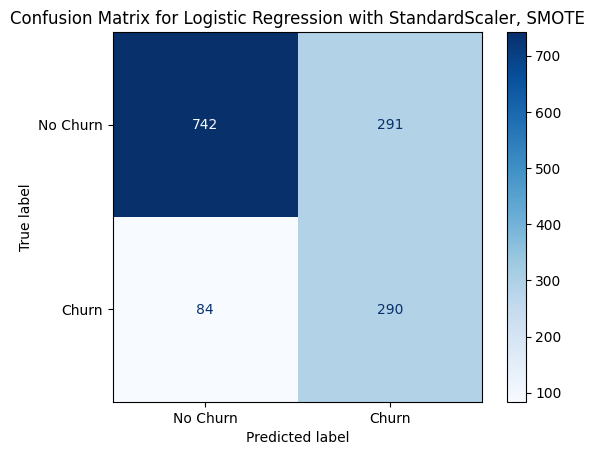

In [65]:
cm_lr_smote = confusion_matrix(y_test, y_pred_smote_lr)
disp_lr_smote = ConfusionMatrixDisplay(confusion_matrix=cm_lr_smote, display_labels=['No Churn', 'Churn'])
disp_lr_smote.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression with StandardScaler, SMOTE')
plt.show()

This confusion matrix visualizes the performance of the model:

*   **True Negatives (Top-Left):** Correctly predicted 'No Churn'.
*   **False Positives (Top-Right):** Incorrectly predicted 'Churn' (Type I error).
*   **False Negatives (Bottom-Left):** Incorrectly predicted 'No Churn' (Type II error, which we want to minimize in churn prediction).
*   **True Positives (Bottom-Right):** Correctly predicted 'Churn'.

### Confusion Matrix for XGBoost Classifier with StandardScaler, SMOTEENN

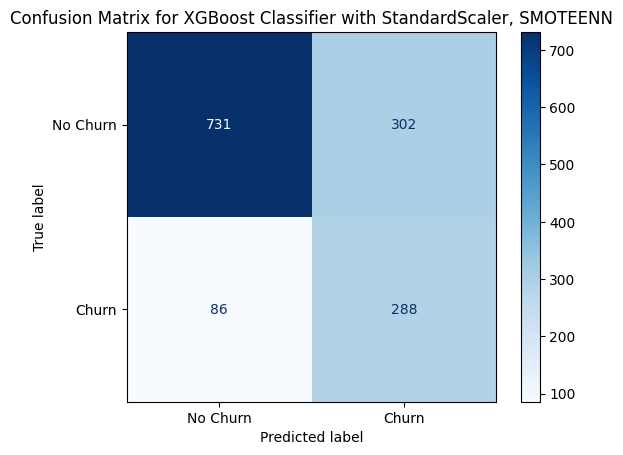

In [67]:
cm_xgb_smnn = confusion_matrix(y_test, y_pred_smnn_xgb)
disp_xgb_smnn = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_smnn, display_labels=['No Churn', 'Churn'])
disp_xgb_smnn.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XGBoost Classifier with StandardScaler, SMOTEENN')
plt.show()

This confusion matrix visualizes the performance of the model:

*   **True Negatives (Top-Left):** Correctly predicted 'No Churn'.
*   **False Positives (Top-Right):** Incorrectly predicted 'Churn' (Type I error).
*   **False Negatives (Bottom-Left):** Incorrectly predicted 'No Churn' (Type II error, which we want to minimize in churn prediction).
*   **True Positives (Bottom-Right):** Correctly predicted 'Churn'.

# 17.Hyper Parameter Optimization

### Hyperparameter Tuning for Logistic Regression with StandardScaler, SMOTE (RandomizedSearchCV)

In [69]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer, classification_report
from scipy.stats import loguniform

# Define the parameter distribution for RandomizedSearchCV
param_dist_lr = {
    'C': loguniform(1e-5, 100),  # Inverse of regularization strength; smaller values specify stronger regularization
    'penalty': ['l1', 'l2']    # Specify the norm used in the penalization
}

# Initialize Logistic Regression model (solver='liblinear' supports both l1 and l2 penalties)
model_lr_tuned = LogisticRegression(random_state=24, solver='liblinear')

# Set up Stratified K-Fold for cross-validation on the SMOTE resampled training data
skf_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

# Use F1-score for the minority class (churn=1) as the scoring metric
f1_scorer_minority = make_scorer(f1_score, pos_label=1)

# Initialize RandomizedSearchCV
random_search_lr = RandomizedSearchCV(
    estimator=model_lr_tuned,
    param_distributions=param_dist_lr,
    n_iter=50,  # Number of parameter settings that are sampled (can be adjusted for efficiency)
    scoring=f1_scorer_minority,
    cv=skf_lr,
    verbose=1,
    random_state=24,
    n_jobs=-1  # Use all available cores
)

# Fit RandomizedSearchCV to the SMOTE resampled training data
random_search_lr.fit(X_train_smote_resampled, y_train_smote_resampled)

# Print the best parameters and best F1-score
print("\nBest parameters found for Logistic Regression:", random_search_lr.best_params_)
print("Best F1-score found for Logistic Regression (on resampled data):", random_search_lr.best_score_)

# Get the best estimator
best_lr_model = random_search_lr.best_estimator_

# Make predictions with the best estimator on the scaled test set (NOT resampled)
y_pred_best_lr = best_lr_model.predict(X_test_scaled)

# Print the classification report for the best model
print("\nClassification Report for Tuned Logistic Regression with StandardScaler and SMOTE:")
print(classification_report(y_test, y_pred_best_lr))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found for Logistic Regression: {'C': np.float64(0.3863690426689655), 'penalty': 'l2'}
Best F1-score found for Logistic Regression (on resampled data): 0.7806950245317356

Classification Report for Tuned Logistic Regression with StandardScaler and SMOTE:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



### XGBoost Classifier with RandomizedSearchCV (No Scaling, No SMOTEENN)

In [71]:
# Define the parameter distribution for RandomizedSearchCV
param_dist_no_preproc = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 1),
    'scale_pos_weight': [scale_pos_weight_value] # Use the pre-calculated value for class imbalance
}

# Initialize the XGBoost Classifier model
model_xgb_no_preproc = XGBClassifier(random_state=24, use_label_encoder=False, eval_metric='logloss')

# Set up Stratified K-Fold for cross-validation
skf_no_preproc = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

# Initialize RandomizedSearchCV
random_search_no_preproc = RandomizedSearchCV(
    estimator=model_xgb_no_preproc,
    param_distributions=param_dist_no_preproc,
    n_iter=100, # Number of parameter settings that are sampled
    scoring='f1',
    cv=skf_no_preproc,
    verbose=1,
    random_state=24,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the original training data
random_search_no_preproc.fit(X_train, y_train)

# Print the best parameters and best F1-score
print("\nBest parameters found (No Scaling, No SMOTEENN):", random_search_no_preproc.best_params_)
print("Best F1-score found (No Scaling, No SMOTEENN):", random_search_no_preproc.best_score_)

# Get the best estimator
best_xgb_model_no_preproc = random_search_no_preproc.best_estimator_

# Make predictions with the best estimator on the original test set
y_pred_best_xgb_no_preproc = best_xgb_model_no_preproc.predict(X_test)

# Print the classification report for the best model
print("\nClassification Report for Tuned XGBoost (No Scaling, No SMOTEENN):")
print(classification_report(y_test, y_pred_best_xgb_no_preproc))

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:37:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found (No Scaling, No SMOTEENN): {'colsample_bytree': np.float64(0.841161573468288), 'gamma': np.float64(0.3796395859349434), 'learning_rate': np.float64(0.013468608664943885), 'max_depth': 4, 'n_estimators': 504, 'reg_alpha': np.float64(0.30925478853644645), 'reg_lambda': np.float64(0.8009320263275697), 'scale_pos_weight': np.float64(2.762541806020067), 'subsample': np.float64(0.6047810852565146)}
Best F1-score found (No Scaling, No SMOTEENN): 0.6354009555441278

Classification Report for Tuned XGBoost (No Scaling, No SMOTEENN):
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



In [72]:
# Define the filename for saving the model
model_filename_no_preproc = 'tuned_xgb_no_preproc_model.joblib'

# Save the best_xgb_model_no_preproc
joblib.dump(best_xgb_model_no_preproc, model_filename_no_preproc)

print(f"Model successfully saved to {model_filename_no_preproc}")

Model successfully saved to tuned_xgb_no_preproc_model.joblib


### XGBoost with StandardScaler only

In [73]:
# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 1000),  # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3),  # Step size shrinkage
    'max_depth': randint(3, 10),        # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4),     # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5),           # Minimum loss reduction required to make a further partition
    'reg_alpha': uniform(0, 0.5),       # L1 regularization term on weights
    'reg_lambda': uniform(0, 1),        # L2 regularization term on weights
    'scale_pos_weight': [scale_pos_weight_value] # Keep fixed as it was already optimized
}

# Initialize the XGBoost Classifier model
model_xgb_tuned = XGBClassifier(random_state=24, use_label_encoder=False, eval_metric='logloss')

# Set up Stratified K-Fold for cross-validation due to imbalanced data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

# Initialize RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled. A higher value leads to more thorough search but longer runtime.
random_search = RandomizedSearchCV(
    estimator=model_xgb_tuned,
    param_distributions=param_dist,
    n_iter=100, # Number of parameter settings that are sampled
    scoring='f1', # Optimize for F1-score of the positive class (churn)
    cv=skf,
    verbose=1,
    random_state=24,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the scaled training data
random_search.fit(X_train_scaled, y_train)

# Print the best parameters and best F1-score
print("\nBest parameters found:", random_search.best_params_)
print("Best F1-score found:", random_search.best_score_)

# Get the best estimator
best_xgb_model = random_search.best_estimator_

# Make predictions with the best estimator on the scaled test set
y_pred_best_xgb = best_xgb_model.predict(X_test_scaled)

# Print the classification report for the best model
print("\nClassification Report for Tuned XGBoost with StandardScaler:")
print(classification_report(y_test, y_pred_best_xgb))

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:41:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found: {'colsample_bytree': np.float64(0.841161573468288), 'gamma': np.float64(0.3796395859349434), 'learning_rate': np.float64(0.013468608664943885), 'max_depth': 4, 'n_estimators': 504, 'reg_alpha': np.float64(0.30925478853644645), 'reg_lambda': np.float64(0.8009320263275697), 'scale_pos_weight': np.float64(2.762541806020067), 'subsample': np.float64(0.6047810852565146)}
Best F1-score found: 0.6354009555441278

Classification Report for Tuned XGBoost with StandardScaler:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



In [74]:
# Define the filename for saving the model
model_filename_standardscaler = 'tuned_xgb_standardscaler_model.joblib'

# Save the best_xgb_model
joblib.dump(best_xgb_model, model_filename_standardscaler)

print(f"Model successfully saved to {model_filename_standardscaler}")

Model successfully saved to tuned_xgb_standardscaler_model.joblib


### XGBoost Classifier with RandomizedSearchCV (with Scaling, with SMOTEENN)

In [75]:
# Define the parameter distribution for RandomizedSearchCV
param_dist_smotenn = {
    'n_estimators': randint(100, 1000),  # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3),  # Step size shrinkage
    'max_depth': randint(3, 10),        # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4),     # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5),           # Minimum loss reduction required to make a further partition
    'reg_alpha': uniform(0, 0.5),       # L1 regularization term on weights
    'reg_lambda': uniform(0, 1)         # L2 regularization term on weights
    # scale_pos_weight is not needed here as SMOTEENN has balanced the classes
}

# Initialize the XGBoost Classifier model
model_xgb_tuned_smotenn = XGBClassifier(random_state=24, use_label_encoder=False, eval_metric='logloss')

# Set up Stratified K-Fold for cross-validation
skf_smotenn = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

# Initialize RandomizedSearchCV
random_search_smotenn = RandomizedSearchCV(
    estimator=model_xgb_tuned_smotenn,
    param_distributions=param_dist_smotenn,
    n_iter=100, # Number of parameter settings that are sampled
    scoring='f1', # Optimize for F1-score of the positive class (churn)
    cv=skf_smotenn,
    verbose=1,
    random_state=24,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the SMOTEENN resampled training data
random_search_smotenn.fit(X_train_resampled, y_train_resampled)

# Print the best parameters and best F1-score
print("\nBest parameters found with SMOTEENN:", random_search_smotenn.best_params_)
print("Best F1-score found with SMOTEENN:", random_search_smotenn.best_score_)

# Get the best estimator
best_xgb_model_smotenn = random_search_smotenn.best_estimator_

# Make predictions with the best estimator on the scaled test set (NOT resampled)
y_pred_best_xgb_smotenn = best_xgb_model_smotenn.predict(X_test_scaled)

# Print the classification report for the best model
print("\nClassification Report for Tuned XGBoost with StandardScaler and SMOTEENN:")
print(classification_report(y_test, y_pred_best_xgb_smotenn))

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found with SMOTEENN: {'colsample_bytree': np.float64(0.7708459075376699), 'gamma': np.float64(0.02697503350736913), 'learning_rate': np.float64(0.05927210863678039), 'max_depth': 7, 'n_estimators': 765, 'reg_alpha': np.float64(0.3121223257524833), 'reg_lambda': np.float64(0.16524827010375842), 'subsample': np.float64(0.9891200420982228)}
Best F1-score found with SMOTEENN: 0.9739793291647885

Classification Report for Tuned XGBoost with StandardScaler and SMOTEENN:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [76]:
# Define the filename for saving the model
model_filename = 'tuned_xgb_smotenn_model.joblib'

# Save the best_xgb_model_smotenn
joblib.dump(best_xgb_model_smotenn, model_filename)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to tuned_xgb_smotenn_model.joblib


### XGBoost Classifier with StandardScaler, Optuna (Bayesian Optimization)

In [77]:
def objective(trial):
    # Define hyperparameters to tune
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'use_label_encoder': False,
        'random_state': 24,
        'scale_pos_weight': scale_pos_weight_value # Use the pre-calculated value
    }

    model = XGBClassifier(**param)

    # Set up Stratified K-Fold for cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

    # Use F1-score as the scoring metric
    f1_scorer = make_scorer(f1_score)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring=f1_scorer, n_jobs=-1)

    return scores.mean()

# Create an Optuna study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100) # Run 100 trials

print("\nBest trial:")
print(f"  Value: {study.best_value:.4f}")
print("  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Train the final model with the best parameters
best_xgb_model_optuna = XGBClassifier(
    random_state=24,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value, # Ensure scale_pos_weight is included
    **study.best_params
)
best_xgb_model_optuna.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_best_xgb_optuna = best_xgb_model_optuna.predict(X_test_scaled)

# Print the classification report for the best model
print("\nClassification Report for Tuned XGBoost with StandardScaler and Optuna:")
print(classification_report(y_test, y_pred_best_xgb_optuna))

[I 2026-04-07 09:47:43,499] A new study created in memory with name: no-name-4bff5c14-dd8f-49a5-92f2-bc4cb1aad69b
[I 2026-04-07 09:47:45,073] Trial 0 finished with value: 0.6093010022016506 and parameters: {'n_estimators': 451, 'learning_rate': 0.12163121855347371, 'max_depth': 8, 'subsample': 0.9897444994953772, 'colsample_bytree': 0.7769468295860456, 'gamma': 0.35322908102876655, 'reg_alpha': 0.3780971609270947, 'reg_lambda': 0.2696836974347079}. Best is trial 0 with value: 0.6093010022016506.
[I 2026-04-07 09:47:48,004] Trial 1 finished with value: 0.5885389759806894 and parameters: {'n_estimators': 935, 'learning_rate': 0.1826743342537714, 'max_depth': 9, 'subsample': 0.8680336454828701, 'colsample_bytree': 0.8717857845595818, 'gamma': 0.44428300684977545, 'reg_alpha': 0.3557071145961954, 'reg_lambda': 0.16784216259185447}. Best is trial 0 with value: 0.6093010022016506.
[I 2026-04-07 09:47:49,998] Trial 2 finished with value: 0.6348359230419222 and parameters: {'n_estimators': 473


Best trial:
  Value: 0.6424
  Params: 
    n_estimators: 344
    learning_rate: 0.01405431364737838
    max_depth: 3
    subsample: 0.7119941415159246
    colsample_bytree: 0.7386588005132104
    gamma: 0.31037461369178526
    reg_alpha: 0.39320020880180395
    reg_lambda: 0.2984078829418895

Classification Report for Tuned XGBoost with StandardScaler and Optuna:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [78]:
# Define the filename for saving the model
model_filename_optuna = 'tuned_xgb_optuna_model.joblib'

# Save the best_xgb_model_optuna
joblib.dump(best_xgb_model_optuna, model_filename_optuna)

print(f"Model successfully saved to {model_filename_optuna}")

Model successfully saved to tuned_xgb_optuna_model.joblib


In [ ]:
# Print the classification report for the best model found by Optuna
print("\nClassification Report for Tuned XGBoost with StandardScaler and Optuna:")
print(classification_report(y_test, y_pred_best_xgb_optuna))


Classification Report for Tuned XGBoost with StandardScaler and Optuna:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



### Comparing F1 scores for predciting minority class and overall accuracy of 5 models

| Model                                                 | F1-score (Minority Class - Churn=1) | Overall Accuracy |
| :---------------------------------------------------- | :---------------------------------- | :--------------- |
| 1. Tuned Logistic Regression (Scaled, SMOTE)          | 0.61                                | 0.73             |
| 2. Tuned XGBoost (No Scaling, No SMOTEENN)            | 0.61                                | 0.73             |
| 3. Tuned XGBoost with StandardScaler                  | 0.61                                | 0.73             |
| 4. Tuned XGBoost with StandardScaler and SMOTEENN     | 0.60                                | 0.73             |
| 5. Tuned XGBoost with StandardScaler and Optuna       | 0.61                                | 0.73             |

**Observations:**

*   Most of the tuned models, including the Logistic Regression with SMOTE and several XGBoost configurations, achieve a consistent F1-score of 0.61 for the minority class and an overall accuracy of 0.73.
*   The Tuned XGBoost with StandardScaler and SMOTEENN had a slightly lower F1-score of 0.60 for the minority class while maintaining the same overall accuracy.
*   This consistency across several models suggests that while tuning helped optimize parameters, the inherent challenge of predicting the minority class might still lead to similar performance plateaus on this specific dataset and split. The models are performing quite similarly in identifying churn, with the F1-score being a key metric for this imbalanced problem.


### Comparing ROC-AUC scores for the five tuned models since F1 scores are so close

In [79]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import joblib

# Define the filename for saving the Logistic Regression model
model_filename_lr = 'tuned_logistic_regr_standardscaled_smote.joblib'

# Save the best_lr_model (retaining original cell purpose)
joblib.dump(best_lr_model, model_filename_lr)
print(f"Logistic Regression model successfully saved to {model_filename_lr}\n")

# Calculate prediction probabilities for all models
y_pred_proba_lr_tuned = best_lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_no_preproc = best_xgb_model_no_preproc.predict_proba(X_test)[:, 1]
y_pred_proba_standardscaler = best_xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_smotenn = best_xgb_model_smotenn.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_optuna = best_xgb_model_optuna.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC scores
roc_auc_lr_tuned = roc_auc_score(y_test, y_pred_proba_lr_tuned)
roc_auc_no_preproc = roc_auc_score(y_test, y_pred_proba_no_preproc)
roc_auc_standardscaler = roc_auc_score(y_test, y_pred_proba_standardscaler)
roc_auc_smotenn = roc_auc_score(y_test, y_pred_proba_smotenn)
roc_auc_optuna = roc_auc_score(y_test, y_pred_proba_optuna)

# Print ROC-AUC scores
print("\n--- ROC-AUC Scores for Tuned Models ---")
print(f"1. Tuned Logistic Regression (Scaled, SMOTE): {roc_auc_lr_tuned:.4f}")
print(f"2. Tuned XGBoost (No Scaling, No SMOTEENN): {roc_auc_no_preproc:.4f}")
print(f"3. Tuned XGBoost with StandardScaler: {roc_auc_standardscaler:.4f}")
print(f"4. Tuned XGBoost with StandardScaler and SMOTEENN: {roc_auc_smotenn:.4f}")
print(f"5. Tuned XGBoost with StandardScaler and Optuna: {roc_auc_optuna:.4f}")


Logistic Regression model successfully saved to tuned_logistic_regr_standardscaled_smote.joblib


--- ROC-AUC Scores for Tuned Models ---
1. Tuned Logistic Regression (Scaled, SMOTE): 0.8236
2. Tuned XGBoost (No Scaling, No SMOTEENN): 0.8343
3. Tuned XGBoost with StandardScaler: 0.8343
4. Tuned XGBoost with StandardScaler and SMOTEENN: 0.8218
5. Tuned XGBoost with StandardScaler and Optuna: 0.8345


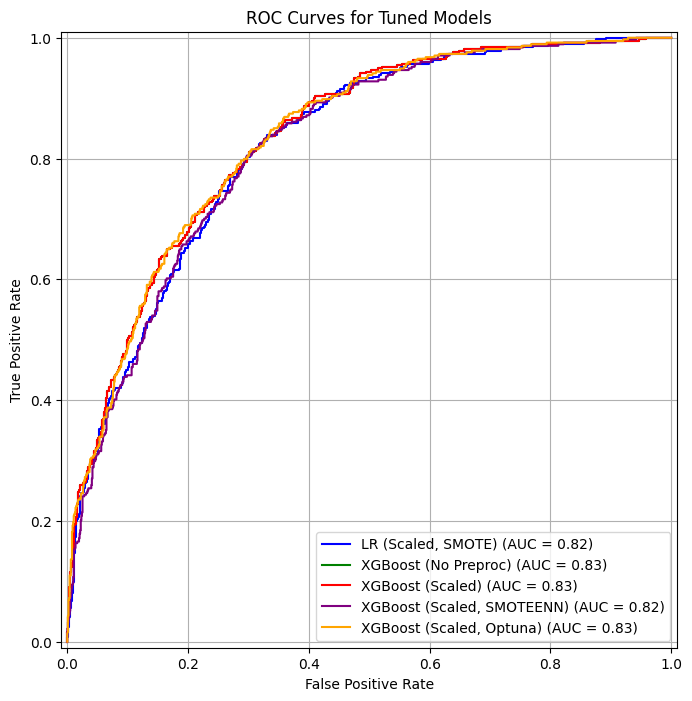

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Create a figure and axes for the plot
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Plot ROC curve for Tuned Logistic Regression (Scaled, SMOTE)
RocCurveDisplay.from_estimator(best_lr_model, X_test_scaled, y_test, ax=ax, name='LR (Scaled, SMOTE)', color='blue')

# Plot ROC curve for Tuned XGBoost (No Scaling, No SMOTEENN)
RocCurveDisplay.from_estimator(best_xgb_model_no_preproc, X_test, y_test, ax=ax, name='XGBoost (No Preproc)', color='green')

# Plot ROC curve for Tuned XGBoost with StandardScaler
RocCurveDisplay.from_estimator(best_xgb_model, X_test_scaled, y_test, ax=ax, name='XGBoost (Scaled)', color='red')

# Plot ROC curve for Tuned XGBoost with StandardScaler and SMOTEENN
RocCurveDisplay.from_estimator(best_xgb_model_smotenn, X_test_scaled, y_test, ax=ax, name='XGBoost (Scaled, SMOTEENN)', color='purple')

# Plot ROC curve for Tuned XGBoost with StandardScaler and Optuna
RocCurveDisplay.from_estimator(best_xgb_model_optuna, X_test_scaled, y_test, ax=ax, name='XGBoost (Scaled, Optuna)', color='orange')


# Add plot title and labels
plt.title('ROC Curves for Tuned Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


* As per classification report and ROC-AUC score for all five tuned models, 2 best models are
1) Tuned XGBoost with StandardScaler and Optuna (Bayesian Optimization)
2) Tuned XGBoost with StandardScaler

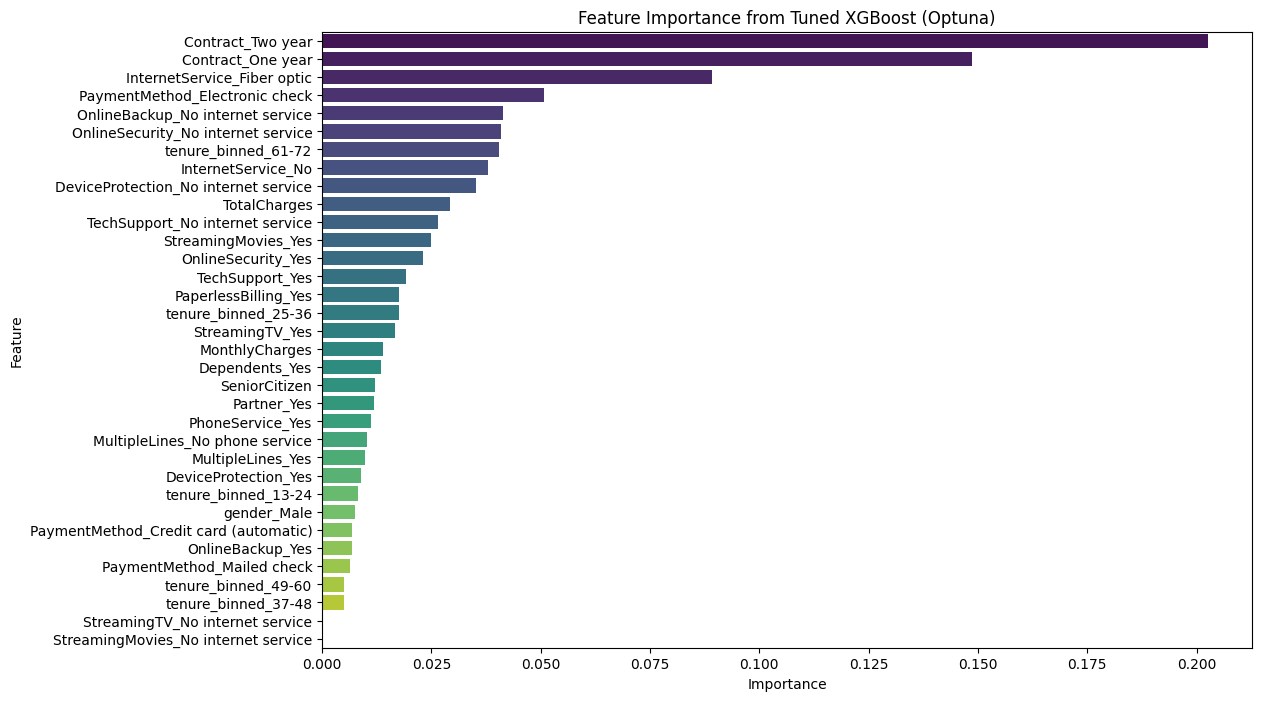

In [82]:
# Get feature importances from the best Optuna XGBoost model
feature_importances = best_xgb_model_optuna.feature_importances_

# Get feature names from X_train (original features before scaling)
feature_names = X_train.columns

# Create a Series for better handling and sorting
importance_series = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
sorted_importance = importance_series.sort_values(ascending=False)

# Plot the top N most important features
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importance.values, y=sorted_importance.index, palette='viridis', hue=sorted_importance.index, legend=False)
plt.title('Feature Importance from Tuned XGBoost (Optuna)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()